In [12]:
import joblib
import shap
import pandas as pd

In [13]:
bundle = joblib.load("stress_model_no_eda.pkl")
model   = bundle["model"]
scaler  = bundle["scaler"]
features = bundle["features"]


In [14]:
df = pd.read_csv("wesad_features.csv")
df = df.dropna(subset=features)

X = df[features]
X_scaled = scaler.transform(X)

/Users/username/PycharmProjects/StressShield/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


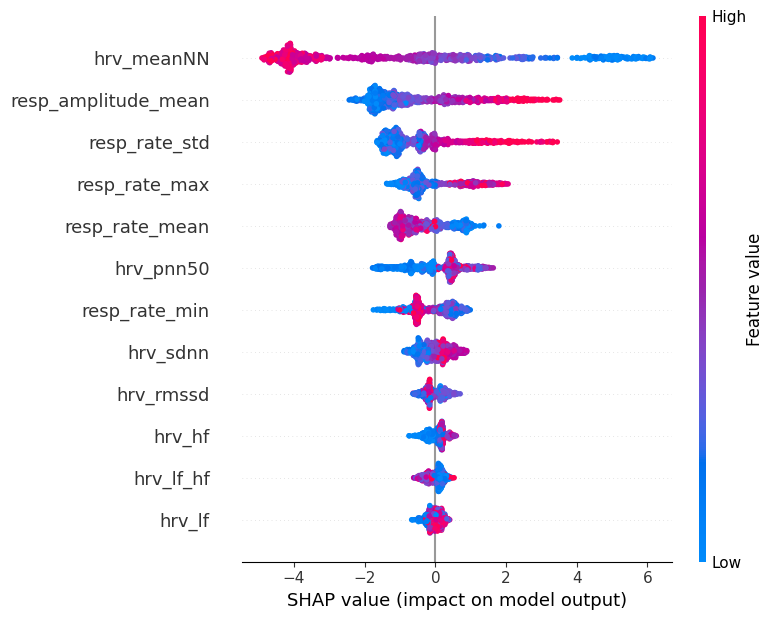

In [15]:
# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)

shap.summary_plot(shap_values, X_scaled, feature_names=features)

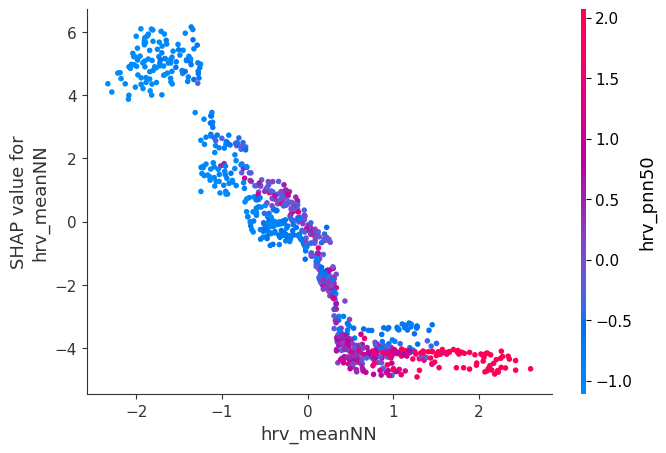

In [16]:
shap.dependence_plot("hrv_meanNN", shap_values, X_scaled, feature_names=features)

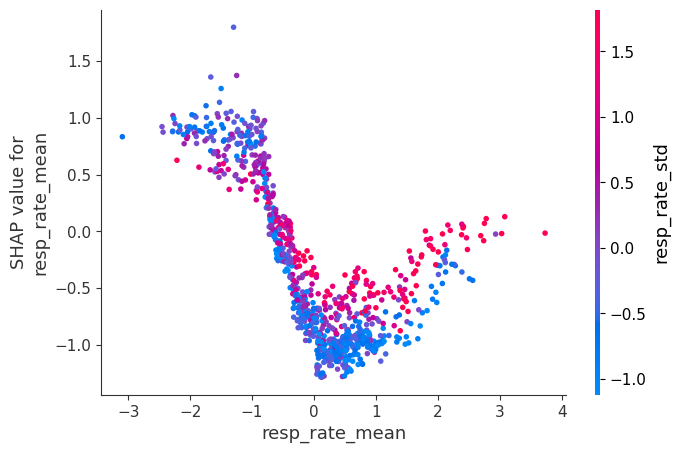

In [17]:
shap.dependence_plot("resp_rate_mean", shap_values, X_scaled, feature_names=features)

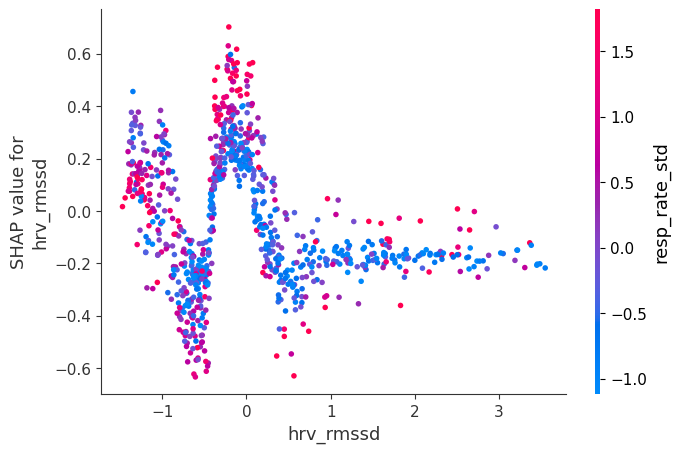

In [18]:
shap.dependence_plot("hrv_rmssd", shap_values, X_scaled, feature_names=features)

In [19]:
import pandas as pd
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)
print(importance)

hrv_meanNN             0.287077
resp_rate_std          0.126429
hrv_pnn50              0.111520
resp_amplitude_mean    0.109265
resp_rate_min          0.072054
resp_rate_max          0.068608
hrv_rmssd              0.062757
resp_rate_mean         0.052611
hrv_hf                 0.030817
hrv_lf_hf              0.030248
hrv_sdnn               0.029606
hrv_lf                 0.019009
dtype: float32
